# COMP3008 CW2

You have been provided with data from the UK Annual Population Survey from January 2019 to December 2024 in two separate csv files. The UK government wants to understand how the COVID-19 pandemic has impacted employment patterns and regional economies.

To do this you need to use a range of big data analysis techniques. The report should contain commentary on the results of each of the analysis techniques you apply to the data and your final insights and recommendations, with justification.

Your report should include how the data has been pre-processed, at least three different methods for exploratory analysis and at least two methods for predictive modelling, where you need to comment on the suitability and accuracy of each of the methods. 

## Report Requirements

- You should write your report so that it is understandable and accessible, you can assume the reader is familiar with the COMP3008 material and do not wish to see it reiterated in your report.
- Your report should provide details of the methods applied for the predictive modelling.
- Your work on this assignment should involve considerable reading and research from multiple appropriate sources—the Internet is a good place to start, but do not stop there; consider also books and preferably academic articles. Include a reference list, and make sure that your report contains citations to the sources in your reference list and using Harvard style referencing.
- When citing sources, ensure that you provide clear and explicit information about the contents of the cited source, so that the relationship between the contents of the source and the points being made are clear

The length of the report should be 3500 words (+/-10%). Include a word count immediately after your report title - *a penalty of 5 marks will be applied for omitting the word count*. Reports exceeding the maximum word length will be penalised. Your reference list is not included in the word count. If you produce appendices, these are not included in the word count. 

## Assessment Criteria

- Literature review (10 Marks)
- Overview of the methods used in report (10 Marks)
- Pre-processing of the data (10 Marks)
- Application of the methods (20 Marks)
- Results (10 Marks)
- Conclusion (5 Marks)
- Reference list (5 Marks)

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df_early = pd.read_csv("./Data/ReportData/AnnualPopulationSurvey_Jan2019_Dec2021.csv")
df_late = pd.read_csv("./Data/ReportData/AnnualPopulationSurvey_Jan2022_Dec2024.csv")

C:\Users\richa\AppData\Local\Temp\ipykernel_9652\3494456411.py:1: DtypeWarning: Columns (39,434) have mixed types. Specify dtype option on import or set low_memory=False.
  df_early = pd.read_csv("./Data/ReportData/AnnualPopulationSurvey_Jan2019_Dec2021.csv")
C:\Users\richa\AppData\Local\Temp\ipykernel_9652\3494456411.py:2: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_late = pd.read_csv("./Data/ReportData/AnnualPopulationSurvey_Jan2022_Dec2024.csv")


## Data Pre-Processing

`AnnualPopulationSurvey_Jan2019_Dec2021.csv` uses `fileyear`, `AnnualPopulationSurvey_Jan2022_Dec2024.csv` uses `FILEYEAR`. All column names should be standardised to uppercase.

> Done before combining to prevent duplicate column names

In [48]:
df_early.columns = df_early.columns.str.upper()
df_late.columns = df_late.columns.str.upper()

In [49]:
df_combined = pd.concat([ df_early, df_late ], ignore_index=True)

In [ ]:
print(f"Records (Early/Late): { df_early.shape[0] }/{ df_late.shape[0] }") # Not equal datasets
print(f"Columns (Early/Late): { len(df_early.columns) }/{ len(df_late.columns) }\n")

print(f"Total Records Combined: { df_combined.shape[0] }")
print(f"Total Columns Combined: { len(df_combined.columns) }\n")

print(f"Head:\n { df_combined.head()}")

---

```
Value = -9.0
Value = -8.0
```

Population Survey data uses specific codes for missing data; need to handle these during pre-processing.

In [51]:
df_combined.replace([ -8.0, -9.0 ], np.nan, inplace=True)

750,000+ records would be overwhelming to plot individually; instead they will be grouped by a time period to reveal trends.

- `REFDTE` Reference date
- `REFWKD` Reference week day
- `REFWKM` Reference week month
- `REFWKY` Reference week year
- `QRTR` Quarter

> https://pandas.pydata.org/docs/reference/api/pandas.Timestamp.to_period.html <br>
> https://pandas.pydata.org/docs/reference/api/pandas.PeriodIndex.html

In [97]:
# print(f"Unique fileyears: {df_combined["fileyear"].unique()}")
# print(f"Missing fileyears: {df_combined["fileyear"].isna().sum()}") # 320,589; implies fileyear completely missing from df_late

print([col for col in df_combined.columns if "YEAR" in col]) # ["FILEYEAR", "FILEYEAR"] duplicate?

# df_late has FILEYEAR, are column names case-sensitive?
print(f"Unique fileyears: {df_combined["FILEYEAR"].unique()}") # appears so
print(f"Missing fileyears: {df_combined["FILEYEAR"].isna().sum()}")

print(f"Unique Quarters: {df_combined["QRTR"].unique()}")

['FILEYEAR', 'YEAR_QUARTER']
Unique fileyears: [2019 2020 2021 2022 2023 2024]
Missing fileyears: 0
Unique Quarters: [1 2 3 4]


In [125]:
df_combined["YEAR_QUARTER"] = df_combined["FILEYEAR"].astype(int).astype(str) + "-Q" + df_combined["QRTR"].astype(int).astype(str)
df_combined["QUARTER_PERIOD"] = pd.PeriodIndex(df_combined["YEAR_QUARTER"], freq="Q")

df_combined = df_combined.sort_values("QUARTER_PERIOD")

print(f"Quarter Periods: {df_combined["QUARTER_PERIOD"].unique()}") # looks sorted yay


Quarter Periods: <PeriodArray>
['2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3',
 '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1', '2022Q2',
 '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1',
 '2024Q2', '2024Q3', '2024Q4']
Length: 24, dtype: period[Q-DEC]


# Heatmap

A heatmap will display which variables have the highest influence on results, and which variables are correlated. If variables are very strongly linked, this can be used to inform PCA decisions and identify and drop redundant variables (co-linearity) improving the computational efficiency of the model analysis.

In [95]:
heatmap_components = [
    "AAGE", "ACTHR", "GRSSWK", "HOURPAY", "AGE", "BUSHR", "TOTAC1", "USUHR", "FILEYEAR", "QRTR"
]

df_heatmap = df_combined[heatmap_components].copy()

correlation_matrix = df_heatmap.corr()


In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="YlOrRd",
    fmt=".2f"
)

plt.title("Correlation Matrix to Identify Co-linear Variables")

plt.savefig("graphs/correlation_matrix.png", dpi=300)
plt.show()

## Time-Series Analysis: Employment Patterns

Used to visualise how the pandemic has impacted employment patterns.

In [126]:
quarterly_trend_data = df_combined.groupby("QUARTER_PERIOD").agg({
    "ACTHR": "mean",
    "GRSSWK": "mean"
}).reset_index()

quarterly_trend_data["QUARTER_STR"] = quarterly_trend_data["QUARTER_PERIOD"].astype(str)

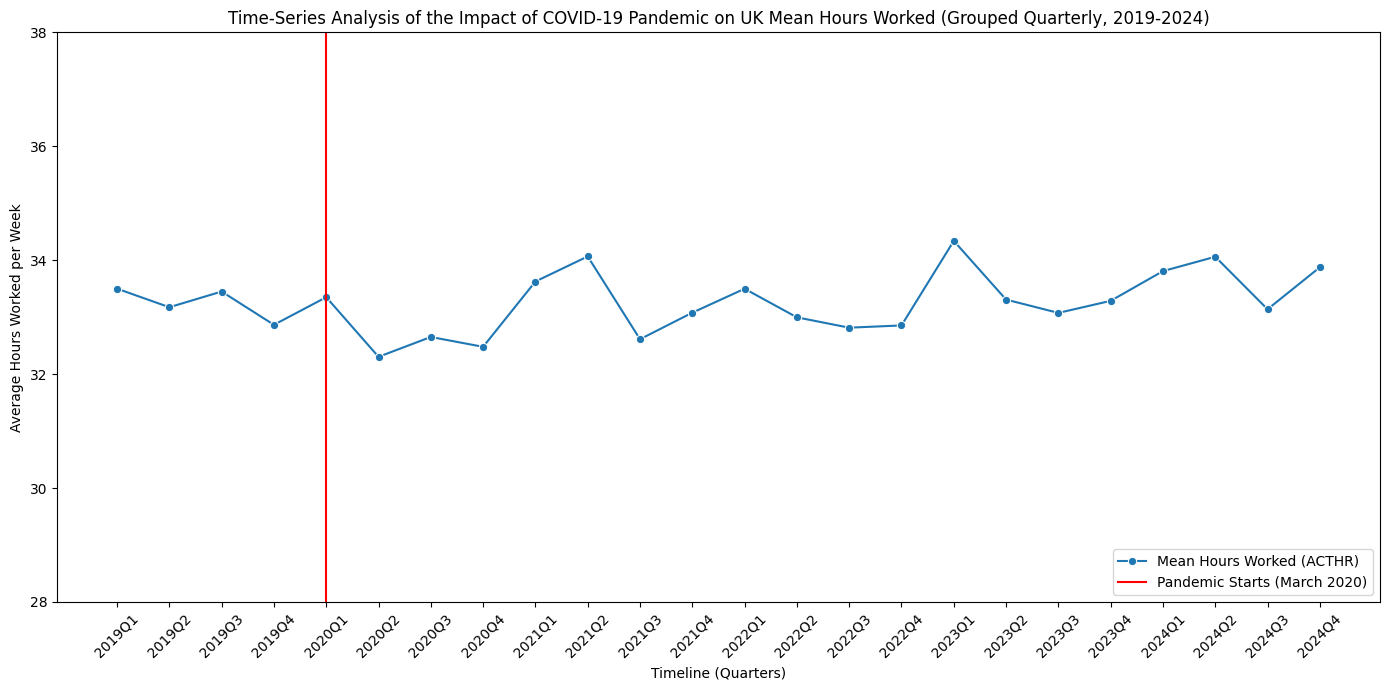

In [127]:
plt.figure(figsize=(14, 7))

sns.lineplot(data=quarterly_trend_data,
             x="QUARTER_STR",
             y="ACTHR",
             marker="o",
             label="Mean Hours Worked (ACTHR)"
)

plt.axvline(x="2020Q1", color="red", label="Pandemic Starts (March 2020)")

plt.title("Time-Series Analysis of the Impact of COVID-19 Pandemic on UK Mean Hours Worked (Grouped Quarterly, 2019-2024)")
plt.xlabel("Timeline (Quarters)")
plt.xticks(rotation=45)

plt.ylabel("Average Hours Worked per Week")
plt.ylim(28, 38)

plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("graphs/time_series_lineplot_hours_worked_by_quarter.png", dpi=300)
plt.show()

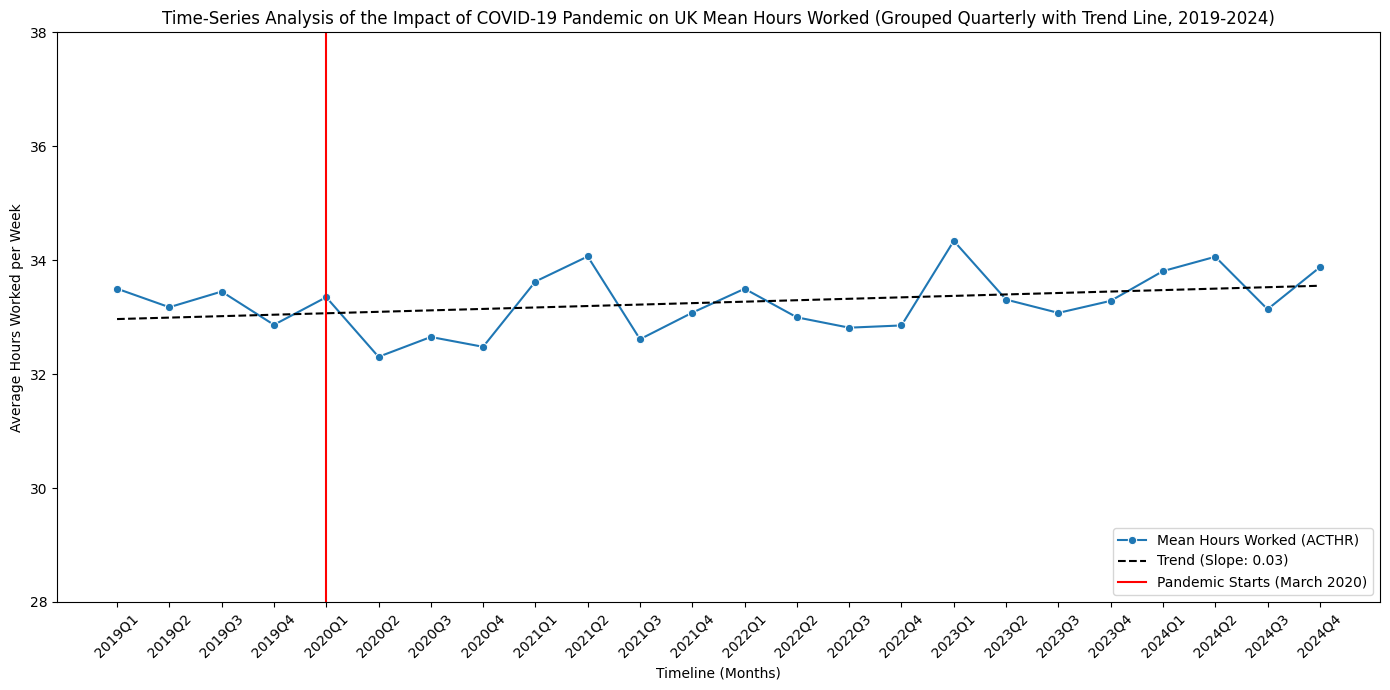

In [128]:
x_series = np.arange(len(quarterly_trend_data))
y_values = quarterly_trend_data["ACTHR"]

slope, intercept = np.polyfit(x_series, y_values, 1)
trendline = slope * x_series + intercept

plt.figure(figsize=(14, 7))

sns.lineplot(data=quarterly_trend_data,
             x="QUARTER_STR",
             y="ACTHR",
             marker="o",
             label="Mean Hours Worked (ACTHR)"
)

plt.plot(quarterly_trend_data["QUARTER_STR"], trendline, label=f"Trend (Slope: {slope:.2f})", color="k", linestyle="--")

plt.axvline(x="2020Q1", color="red", label="Pandemic Starts (March 2020)")

plt.title("Time-Series Analysis of the Impact of COVID-19 Pandemic on UK Mean Hours Worked (Grouped Quarterly with Trend Line, 2019-2024)")

plt.xlabel("Timeline (Months)")
plt.xticks(rotation=45)

plt.ylabel("Average Hours Worked per Week")
plt.ylim(28, 38)

plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("graphs/time_series_lineplot_hours_worked_by_quarter_trendline.png", dpi=300)
plt.show()

In [129]:
df_combined["MONTH_STR"] = df_combined["REFWKY"].astype(int).astype(str) + "-" + df_combined["REFWKM"].astype(int).astype(str).str.zfill(2) + "-01"
df_combined["MONTHLY_PERIOD"] = pd.to_datetime(df_combined["MONTH_STR"]).dt.to_period("M")

monthly_trend_data = df_combined.groupby("MONTHLY_PERIOD").agg({
    "ACTHR": "mean",
    "GRSSWK": "mean"
}).reset_index()

monthly_trend_data["MONTH_STR"] = monthly_trend_data["MONTHLY_PERIOD"].astype(str)

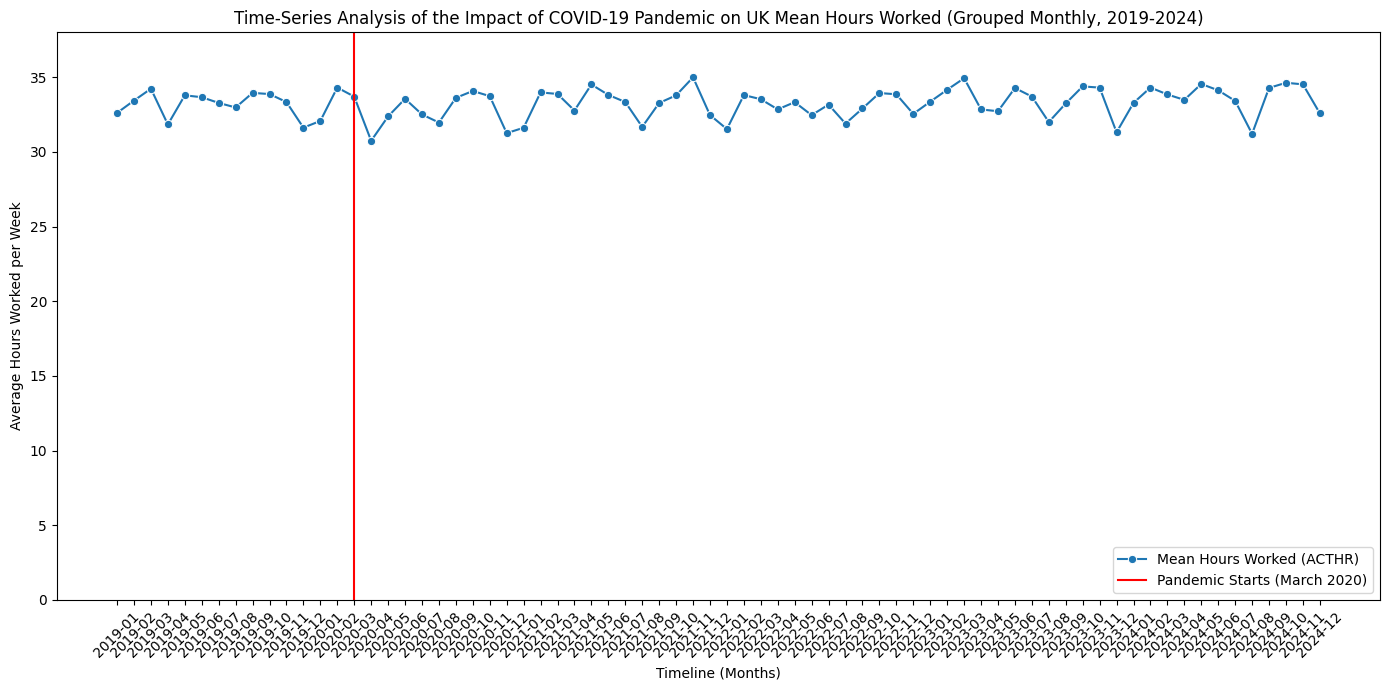

In [ ]:
plt.figure(figsize=(14, 7))

sns.lineplot(data=monthly_trend_data,
             x="MONTH_STR",
             y="ACTHR",
             marker="o",
             label="Mean Hours Worked (ACTHR)"
)

plt.axvline(x="2020-03", color="red", label="Pandemic Starts (March 2020)")

plt.title("Time-Series Analysis of the Impact of COVID-19 Pandemic on UK Mean Hours Worked (Grouped Monthly, 2019-2024)")

plt.xlabel("Timeline (Months)")
plt.xticks(rotation=45)

plt.ylabel("Average Hours Worked per Week")
plt.ylim(0, 38)

plt.legend(loc="lower right")

plt.tight_layout()
plt.savefig("graphs/time_series_lineplot_hours_worked_by_month.png", dpi=300)
plt.show()

## Regional Impacts

A comparison of `COUNTRY` against `ACTHR` (Actual Hours (excluding overtime))

In [131]:
country_map = {
    1: "England",
    2: "Wales",
    3: "Scotland",
    4: "Scotland North of Caledonian Canal",
    5: "Northern Ireland"
}

country_map_scottish_combined = {
    **country_map,
    4: "Scotland"
}

df_combined["COUNTRY_NAME"] = df_combined["COUNTRY"].map(country_map)
df_combined["COUNTRY_NAME_SCOTTISH_COMBINED"] = df_combined["COUNTRY"].map(country_map_scottish_combined)

In [153]:
all_regions = sorted(df_combined["COUNTRY_NAME"].dropna().unique())
palette = dict(zip(all_regions, sns.color_palette("husl", len(all_regions))))

In [145]:
# Apply mask to outlier datapoint
mask = (df_combined["COUNTRY_NAME"] == "Scotland North of Caledonian Canal") & (df_combined["QUARTER_PERIOD"] == "2024Q4")
df_combined.loc[mask, "ACTHR"] = np.nan

In [147]:
raw_scottish = df_combined.groupby(["QUARTER_PERIOD", "COUNTRY_NAME"])["ACTHR"].mean().unstack()
comb_scottish = df_combined.groupby(["QUARTER_PERIOD", "COUNTRY_NAME_SCOTTISH_COMBINED"])["ACTHR"].mean().unstack()

# X-axis labels:
x_labels = raw_scottish.index.astype(str)

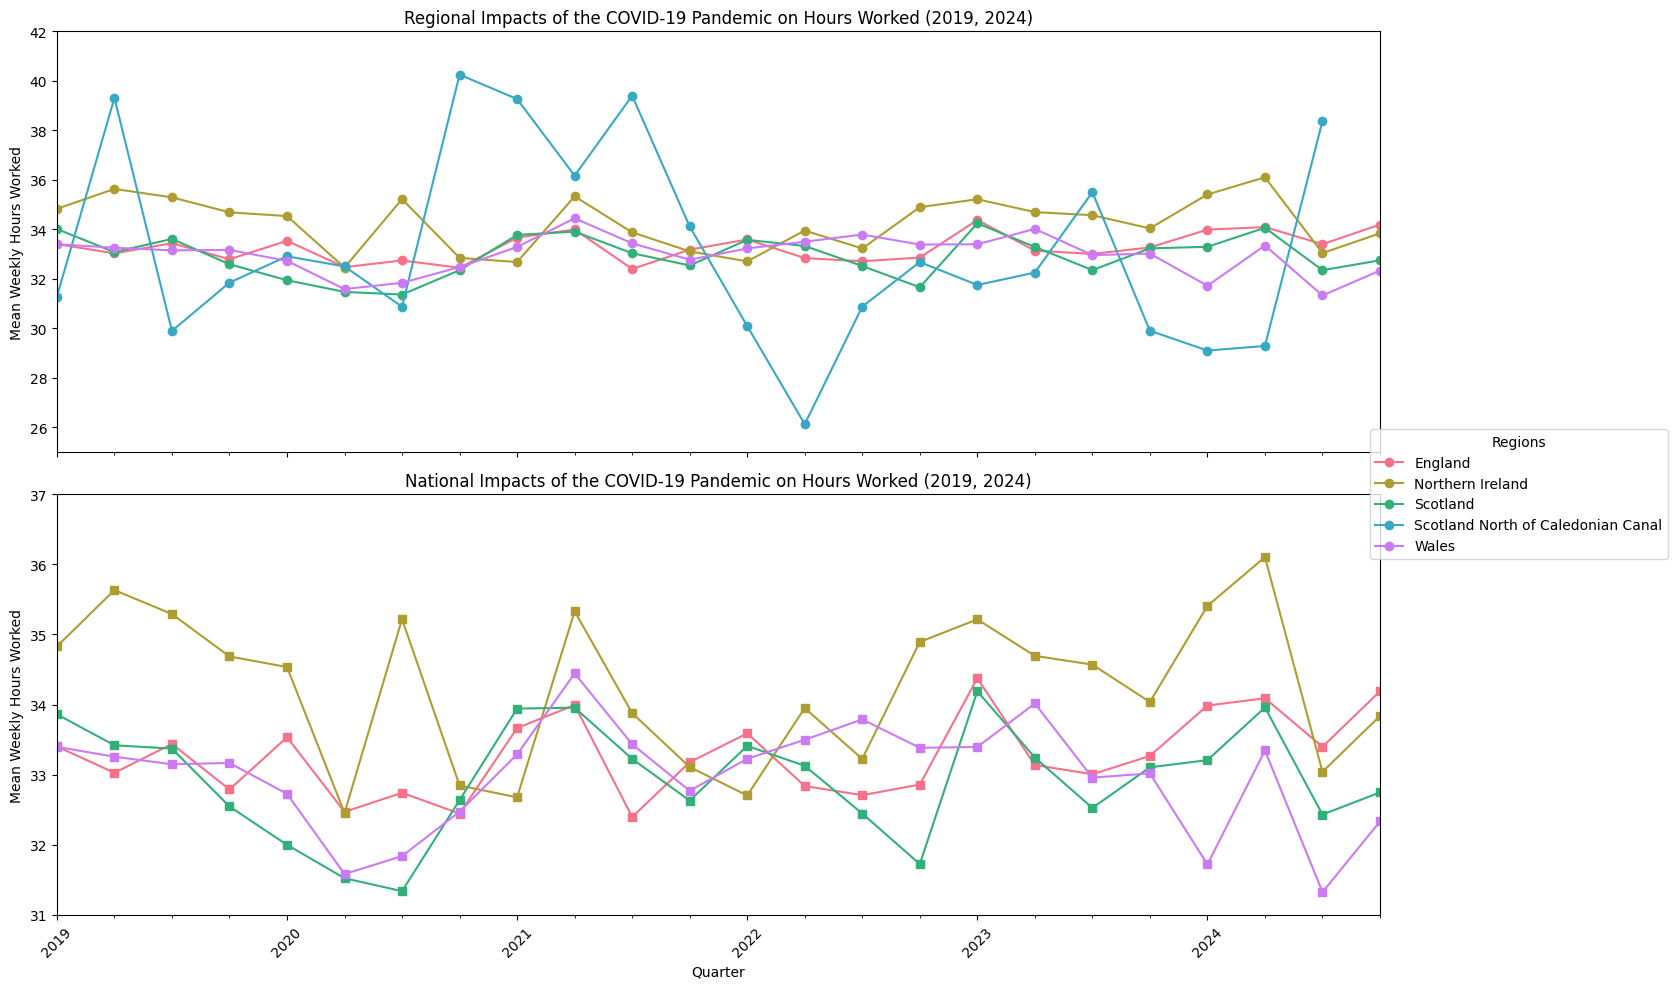

In [180]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

raw_scottish.plot(
    ax=ax1, 
    marker="o", 
    color=[palette.get(c) for c in raw_scottish.columns], 
    legend=False
)

ax1.set_title("Regional Impacts of the COVID-19 Pandemic on Hours Worked (2019, 2024)")

ax1.set_ylabel("Mean Weekly Hours Worked")
ax1.set_ylim(25, 42)

comb_scottish.plot(
    ax=ax2, 
    marker="s", 
    color=[palette.get(c) for c in comb_scottish.columns], 
    legend=False
)

ax2.set_title("National Impacts of the COVID-19 Pandemic on Hours Worked (2019, 2024)")

ax2.set_ylabel("Mean Weekly Hours Worked")
ax2.set_ylim(31, 37)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="Regions", bbox_to_anchor=(1.2, 0.5))

plt.xlabel("Quarter")
plt.xticks(rotation=45)

plt.subplots_adjust(right=0.85)
plt.tight_layout()

plt.savefig("graphs/regional_impacts_masked.png", dpi=300, bbox_inches="tight")
plt.show()

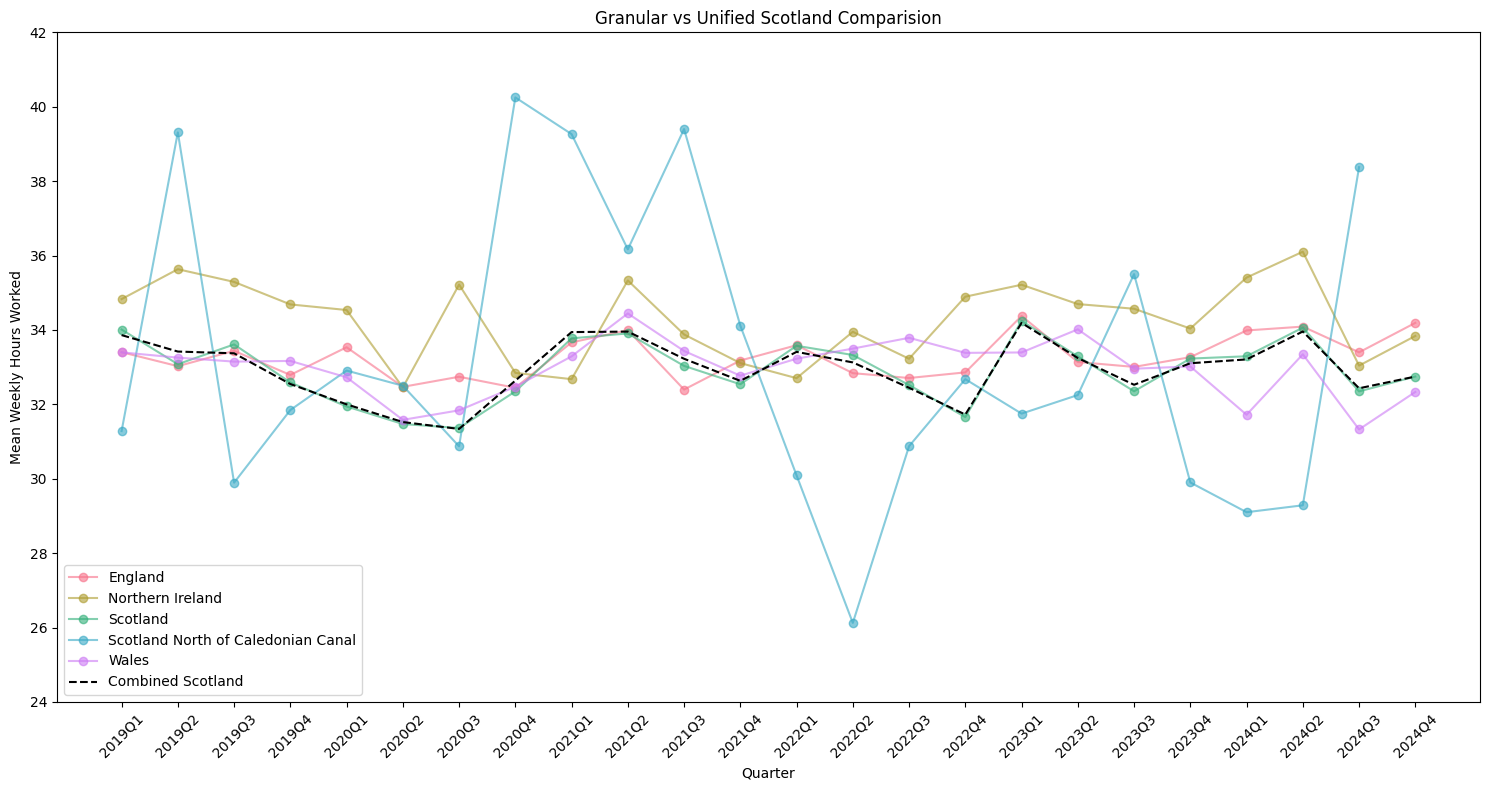

In [ ]:
plt.figure(figsize=(15, 8))

for column in raw_scottish.columns:
    plt.plot(
        x_labels, 
        raw_scottish[column].values, 
        marker="o", 
        label=column,
        color=palette.get(column),
        alpha=0.6
    )
    
plt.plot(
    x_labels, 
    comb_scottish["Scotland"].values, 
    color="black", 
    label="Combined Scotland",
    linestyle="--"
)

plt.title("Granular vs Unified Scotland Comparision")
plt.xlabel("Quarter")

plt.ylabel("Mean Weekly Hours Worked")

plt.legend(loc="lower left")

plt.xticks(rotation=45)
plt.ylim(24, 42)

plt.tight_layout()

plt.savefig("graphs/regional_impacts_scottish_comparison.png", dpi=300)
plt.show()

